In [104]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, pathlib
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(name)s — %(levelname)s: %(message)s",
    force=True,
)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

sys.path.insert(0, str(pathlib.Path("../..").resolve()))

from ai_playground.mlp.mlp import MLP
from ai_playground.mlp.activations import ReLU, Sigmoid, Linear, Tanh, Softmax
from ai_playground.mlp.losses import BinaryCrossEntropy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## XOR — what a single perceptron cannot do, an MLP can

XOR is not linearly separable, so a single perceptron fails on it.
An MLP with one hidden layer can learn the non-linear decision boundary
by composing two linear boundaries in the hidden layer.

Architecture: **2 → 4 → 1** with ReLU hidden units and a Sigmoid output,
trained with binary cross-entropy loss.

In [94]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)  # XOR labels, shape (4,1)

hidden_activation = Sigmoid()

np.random.seed(0)
mlp = MLP(
    layer_sizes=[2, 4, 1],
    hidden_activation=hidden_activation,
    output_activation=Sigmoid(),
    loss=BinaryCrossEntropy(),
)

losses = mlp.train(X, y, epochs=1000, lr=0.1, log_every=10)

preds = mlp.predict(X)
print("Raw outputs:  ", preds.ravel().round(4))
print("Rounded:      ", preds.ravel().round().astype(int))
print("Expected:     ", y.ravel().astype(int))

ai_playground.mlp.mlp — INFO: Epoch 10/1000  loss=2.800503
ai_playground.mlp.mlp — INFO: Epoch 20/1000  loss=2.779337
ai_playground.mlp.mlp — INFO: Epoch 30/1000  loss=2.761845
ai_playground.mlp.mlp — INFO: Epoch 40/1000  loss=2.746353
ai_playground.mlp.mlp — INFO: Epoch 50/1000  loss=2.731655
ai_playground.mlp.mlp — INFO: Epoch 60/1000  loss=2.716814
ai_playground.mlp.mlp — INFO: Epoch 70/1000  loss=2.701132
ai_playground.mlp.mlp — INFO: Epoch 80/1000  loss=2.684121
ai_playground.mlp.mlp — INFO: Epoch 90/1000  loss=2.665456
ai_playground.mlp.mlp — INFO: Epoch 100/1000  loss=2.644914
ai_playground.mlp.mlp — INFO: Epoch 110/1000  loss=2.622322
ai_playground.mlp.mlp — INFO: Epoch 120/1000  loss=2.597503
ai_playground.mlp.mlp — INFO: Epoch 130/1000  loss=2.570240
ai_playground.mlp.mlp — INFO: Epoch 140/1000  loss=2.540268
ai_playground.mlp.mlp — INFO: Epoch 150/1000  loss=2.507274
ai_playground.mlp.mlp — INFO: Epoch 160/1000  loss=2.470921
ai_playground.mlp.mlp — INFO: Epoch 170/1000  los

Raw outputs:   [0.037  0.9615 0.9675 0.0272]
Rounded:       [0 1 1 0]
Expected:      [0 1 1 0]


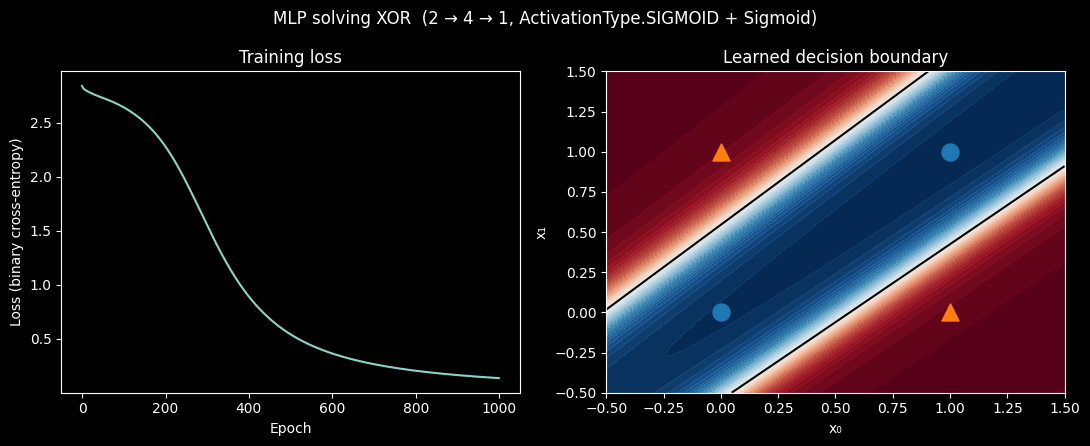

In [95]:
fig, (ax_loss, ax_boundary) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: training loss curve
ax_loss.plot(losses)
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss (binary cross-entropy)")
ax_loss.set_title("Training loss")
#ax_loss.set_yscale("log")

# Right: learned decision boundary over the unit square
res = 200
xs = np.linspace(-0.5, 1.5, res)
grid = np.array([[x0, x1] for x1 in xs for x0 in xs])
probs = mlp.predict(grid).reshape(res, res)

ax_boundary.contourf(xs, xs, probs, levels=50, cmap="RdBu_r", alpha=0.8)
ax_boundary.contour(xs, xs, probs, levels=[0.5], colors="k", linewidths=1.5)
for (x0, x1), label in zip(X, y.ravel()):
    ax_boundary.scatter(x0, x1, marker=("^" if label else "o"), s=150,
                        color=("tab:orange" if label else "tab:blue"), zorder=5)
ax_boundary.set_title("Learned decision boundary")
ax_boundary.set_xlabel("x₀")
ax_boundary.set_ylabel("x₁")

hidden_name = hidden_activation.name
plt.suptitle(f"MLP solving XOR  (2 → 4 → 1, {hidden_name} + Sigmoid)", fontsize=12)
plt.tight_layout()
plt.show()

## How often do we fail to learn XOR with ReLU vs Sigmoid hidden activation?

In [38]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)  # XOR labels, shape (4,1)

In [116]:
def run_xor_experiment(seed: int, hidden_activation=ReLU(),
                       epochs=1000, lr=0.1, num_hidden_layers=4):
    np.random.seed(seed)
    mlp = MLP(
        layer_sizes=[2, num_hidden_layers, 1],
        hidden_activation=hidden_activation,
        output_activation=Sigmoid(),
        loss=BinaryCrossEntropy(),
        seed=seed
    )
    losses = mlp.train(X, y, epochs=epochs, lr=lr, log_every=0)
    final_loss = losses[-1]
    preds = mlp.predict(X).round().astype(int)
    return np.mean(preds == y), final_loss

def run_multiple_xor_experiments(num_runs: int = 100,
                                 hidden_activation=ReLU(),
                                 epochs=1000, lr=0.1,
                                 num_hidden_layers=4):
    """
    Runs multiple runs of XOR experiments, outputting a DataFrame with final accuracy and loss for each run.
    """
    results = []
    for seed in range(num_runs):
        acc, loss = run_xor_experiment(seed, hidden_activation,
                                       epochs=epochs, lr=lr,num_hidden_layers=num_hidden_layers)
        results.append({"seed": seed, "accuracy": acc, "final_loss": loss})
    return pd.DataFrame(results)

### ReLu hidden activation (1000 epochs, lr=0.1)
About 1/3 of runs fail to learn XOR (final loss near 2*log(2) instead of 4*log(2))

In [77]:
df = run_multiple_xor_experiments(1000)

,seed,accuracy,final_loss
0,0,1.00,0.024578
1,1,1.00,0.008501
2,2,1.00,0.009171
3,3,0.75,1.910493
4,4,1.00,0.018509


In [86]:
df.accuracy.value_counts()

accuracy
1.00    644
0.75    319
0.50     34
0.25      3
Name: count, dtype: int64

In [78]:
[i*np.log(2) for i in range(1,5)]

[np.float64(0.6931471805599453),
 np.float64(1.3862943611198906),
 np.float64(2.0794415416798357),
 np.float64(2.772588722239781)]

In [87]:
# Count of final losses near 2 and 4 times log(2)
range2 = (1.3, 1.4)
range4 = (2.7, 2.8)
pct_range2 = ((df.final_loss >= range2[0]) & (df.final_loss <= range2[1])).mean()
pct_range4 = ((df.final_loss >= range4[0]) & (df.final_loss <= range4[1])).mean()
print(f"Final loss near 2*log(2): {pct_range2:.1%}")
print(f"Final loss near 4*log(2): {pct_range4:.1%}")

Final loss near 2*log(2): 17.9%
Final loss near 4*log(2): 3.8%


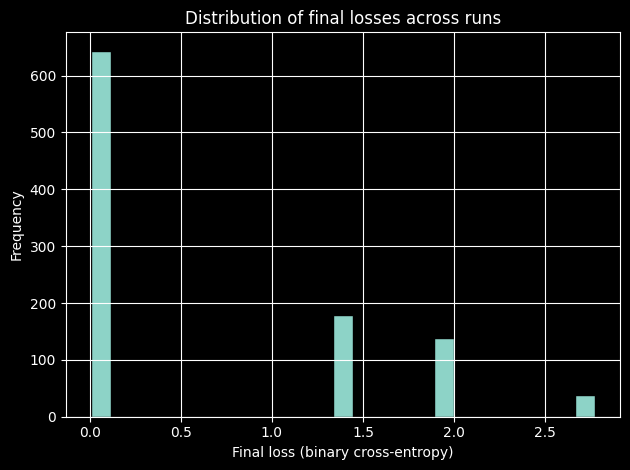

In [89]:
# Hist of final losses
df.hist(column="final_loss", bins=25, edgecolor="k")
plt.title("Distribution of final losses across runs")
plt.xlabel("Final loss (binary cross-entropy)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [82]:
sorted(df.final_loss.values)

[np.float64(0.0065385946640595),
 np.float64(0.006721329414910675),
 np.float64(0.006796027979232239),
 np.float64(0.0069686666941312985),
 np.float64(0.006978261903885318),
 np.float64(0.006987117115715527),
 np.float64(0.007012435299593166),
 np.float64(0.007013583119007024),
 np.float64(0.007023789297314582),
 np.float64(0.007037565800356013),
 np.float64(0.007055196028859185),
 np.float64(0.007055342990824125),
 np.float64(0.007072366738048445),
 np.float64(0.0070990899561923435),
 np.float64(0.007132062486427138),
 np.float64(0.007150405542807086),
 np.float64(0.0071886996608127515),
 np.float64(0.0072073558903983335),
 np.float64(0.0072261888752639235),
 np.float64(0.007232029434570098),
 np.float64(0.007250175009480286),
 np.float64(0.0072532371659729915),
 np.float64(0.00725634706699097),
 np.float64(0.00730386756323292),
 np.float64(0.007307022905831229),
 np.float64(0.007310575254456391),
 np.float64(0.007330694524440361),
 np.float64(0.00736915948945903),
 np.float64(0.00737

### Sigmoid hidden activation (1000 epochs, lr=0.1)

In [100]:
df_sigmoid = run_multiple_xor_experiments(1000,
                                          hidden_activation=Sigmoid())


In [101]:
df_sigmoid.accuracy.value_counts()


accuracy
1.00    952
0.75     32
0.50     16
Name: count, dtype: int64

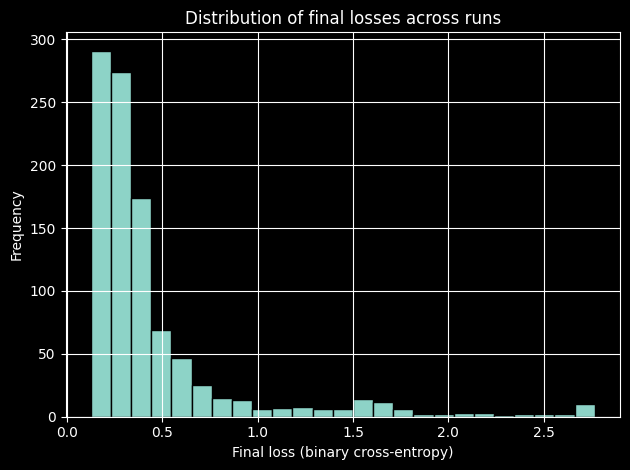

In [102]:
# Hist of final losses
df_sigmoid.hist(column="final_loss", bins=25, edgecolor="k")
plt.title("Distribution of final losses across runs")
plt.xlabel("Final loss (binary cross-entropy)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Tanh hidden activation (1000 epochs, lr=0.1)

In [105]:
df_tanh = run_multiple_xor_experiments(1000,
                                       hidden_activation=Tanh())

In [106]:
df_tanh.accuracy.value_counts()

accuracy
1.0    968
0.5     32
Name: count, dtype: int64

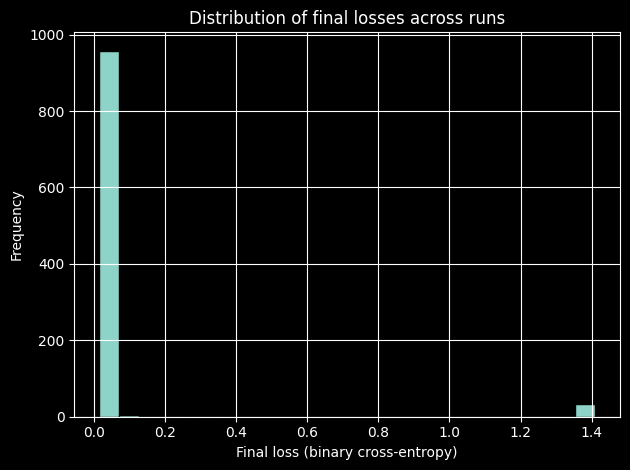

In [107]:
# Hist of final losses
df_tanh.hist(column="final_loss", bins=25, edgecolor="k")
plt.title("Distribution of final losses across runs")
plt.xlabel("Final loss (binary cross-entropy)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Sigmoid hidden activation with more epochs (5000) and higher learning rate (0.25)

In [109]:
df_sigmoid_long = run_multiple_xor_experiments(1000,
                                               hidden_activation=Sigmoid(),
                                               epochs=5000, lr=0.25)

In [110]:
df_sigmoid_long.accuracy.value_counts()

accuracy
1.0    997
0.5      3
Name: count, dtype: int64

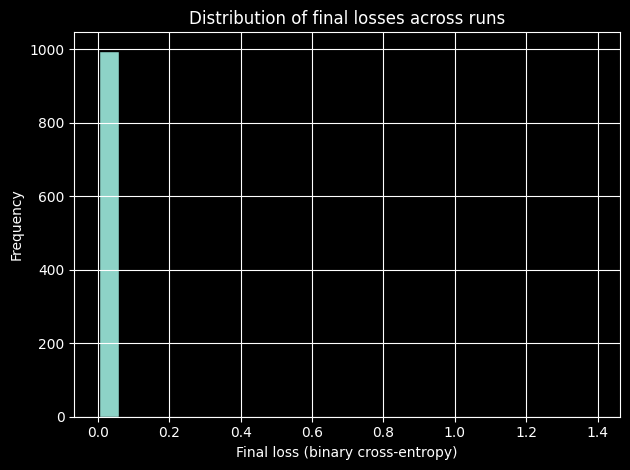

In [111]:
# Hist of final losses
df_sigmoid_long.hist(column="final_loss", bins=25, edgecolor="k")
plt.title("Distribution of final losses across runs")
plt.xlabel("Final loss (binary cross-entropy)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Tanh hidden activation with more epochs (5000) and higher learning rate (0.25)

In [112]:
df_tanh_long = run_multiple_xor_experiments(1000,
                                       hidden_activation=Tanh(),
                                       epochs=5000, lr=0.25)

In [113]:
df_tanh_long.accuracy.value_counts()


accuracy
1.00    982
0.50     17
0.75      1
Name: count, dtype: int64

### Sigmoid hidden activation with more hidden units (10) and 1000 epochs, lr=0.1

In [117]:
df_sigmoid_wider = run_multiple_xor_experiments(1000,
                                               hidden_activation=Sigmoid(),
                                               epochs=1000, lr=0.1, num_hidden_layers=10)

In [118]:
df_sigmoid_wider.accuracy.value_counts()


accuracy
1.0    1000
Name: count, dtype: int64

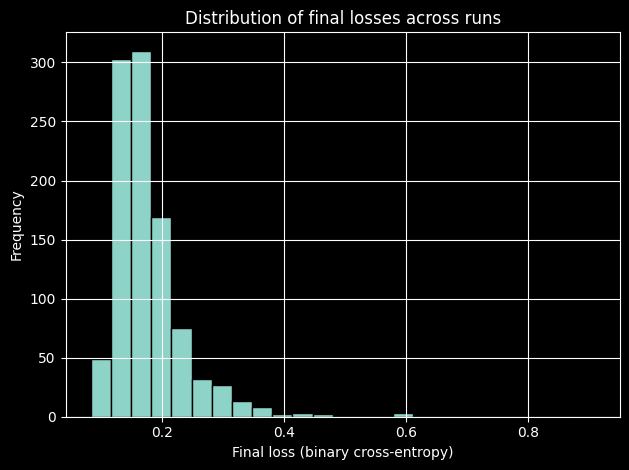

In [119]:
# Hist of final losses
df_sigmoid_wider.hist(column="final_loss", bins=25, edgecolor="k")
plt.title("Distribution of final losses across runs")
plt.xlabel("Final loss (binary cross-entropy)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()